# Statistical Audit of pandas-dev/pandas



## Member Information
- **Name:** Ahmad Aqil Fadria
- **Role:** Data Engineer

---

# Research Questions

1. Berapa perkiraan probabilitas bahwa sebuah pull request akan digabungkan ke pandas-dev/pandas?

2. Apakah rata-rata durasi penutupan issue telah berubah secara signifikan setelah rilis utama pandas?

3. Berapa probabilitas bahwa issue yang dipilih secara acak membutuhkan waktu lebih dari 30 hari untuk ditutup?

---

# Import Libraries

In [23]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub API Configuration

Pada bagian ini dilakukan konfigurasi repository GitHub
dan endpoint API yang digunakan untuk mengambil data
issue dan pull request dari repository pandas-dev/pandas.

Konfigurasi ini digunakan sebagai dasar proses pengambilan data
menggunakan GitHub REST API sehingga notebook dapat
mengakses data repository secara otomatis.


In [24]:
OWNER = "pandas-dev"
REPO = "pandas"

BASE_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/issues"

# GitHub Personal Access Token
TOKEN = "ghp_xxxxxxxxxxxxxx"

headers = {
    "Authorization": f"token {TOKEN}",
    "Accept": "application/vnd.github+json"
}


# Collect Issues Data

Pada bagian ini dilakukan proses pengambilan data issue
dari GitHub REST API pada repository pandas-dev/pandas.

Data yang dikumpulkan mencakup issue dengan status
open maupun closed yang nantinya akan digunakan
untuk proses cleaning, exploratory data analysis (EDA),
dan analisis statistik pada tahap berikutnya.


In [25]:
all_issues = []

for page in range(1, 51):

    url = (
        f"{BASE_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(
        url,
        headers=headers
    )


    if response.status_code != 200:
        print(f"Error collecting page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_issues.extend(data)


    print("Total raw data:",
      len(all_issues))

Total raw data: 100
Total raw data: 200
Total raw data: 300
Total raw data: 400
Total raw data: 500
Total raw data: 600
Total raw data: 700
Total raw data: 800
Total raw data: 900
Total raw data: 1000
Total raw data: 1100
Total raw data: 1200
Total raw data: 1300
Total raw data: 1400
Total raw data: 1500
Total raw data: 1600
Total raw data: 1700
Total raw data: 1800
Total raw data: 1900
Total raw data: 2000
Total raw data: 2100
Total raw data: 2200
Total raw data: 2300
Total raw data: 2400
Total raw data: 2500
Total raw data: 2600
Total raw data: 2700
Total raw data: 2800
Total raw data: 2900
Total raw data: 3000
Total raw data: 3100
Total raw data: 3200
Total raw data: 3300
Total raw data: 3400
Total raw data: 3500
Total raw data: 3600
Total raw data: 3700
Total raw data: 3800
Total raw data: 3900
Total raw data: 4000
Total raw data: 4100
Total raw data: 4200
Total raw data: 4300
Total raw data: 4400
Total raw data: 4500
Total raw data: 4600
Total raw data: 4700
Total raw data: 4800
T

# Convert to DataFrame

Data hasil pengambilan dari GitHub API masih berbentuk
JSON sehingga perlu dikonversi menjadi pandas DataFrame.

Proses ini dilakukan agar data lebih mudah dibaca,
dibersihkan, dianalisis, dan divisualisasikan
pada tahap selanjutnya.


In [26]:
df = pd.DataFrame(all_issues)

print(df.shape)

(5000, 37)


# Save Raw Dataset

Dataset asli hasil pengambilan dari GitHub API
disimpan tanpa perubahan ke dalam folder raw.

Penyimpanan data mentah ini bertujuan untuk menjaga
keaslian data sebelum dilakukan proses cleaning
dan preprocessing lebih lanjut.


In [27]:
import os

output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(f"{output_dir}/issues_raw.csv", index=False)

print("Raw dataset saved.")

Raw dataset saved.


# Filter True Issues

Endpoint issues pada GitHub juga dapat mengandung
data pull request sehingga perlu dilakukan proses filtering.

Pada bagian ini dilakukan pemisahan data agar
dataset hanya berisi issue yang sebenarnya
dan tidak mencampurkan data pull request.


In [28]:
# ============================================================
# CLEAN ISSUE DATA
# ============================================================

issues_df = df.copy()

# ambil hanya closed
issues_df = issues_df[
    issues_df["state"] == "closed"
].copy()

print(issues_df.shape)

(4389, 37)


# Select Important Columns

Pada bagian ini dipilih beberapa kolom penting
yang relevan untuk kebutuhan analisis statistik.

Pemilihan kolom dilakukan agar dataset menjadi
lebih ringkas, mudah diproses, dan fokus
pada variabel yang akan dianalisis.


In [29]:
issues_df = issues_df[
    [
        "id",
        "number",
        "title",
        "state",
        "created_at",
        "closed_at",
        "comments"
    ]
]

# Datetime Conversion

Kolom yang berisi informasi waktu dikonversi
ke format datetime pada pandas.

Proses ini dilakukan agar data waktu dapat
digunakan untuk analisis durasi, perhitungan selisih waktu,
serta kebutuhan analisis statistik lainnya.


In [30]:
issues_df["created_at"] = pd.to_datetime(
    issues_df["created_at"]
)

issues_df["closed_at"] = pd.to_datetime(
    issues_df["closed_at"]
)

# Feature Engineering

Pada bagian ini dilakukan pembuatan variabel baru
yang dibutuhkan untuk analisis statistik.

Variabel tambahan dibuat berdasarkan data yang sudah ada
agar proses analisis, visualisasi, dan interpretasi data
dapat dilakukan dengan lebih mudah.


In [31]:
issues_df["close_duration_days"] = (
    issues_df["closed_at"] - issues_df["created_at"]
).dt.days

issues_df["is_closed"] = 1

# Save Clean Dataset

Dataset yang telah melalui proses cleaning
dan preprocessing disimpan ke dalam folder clean.

Dataset bersih ini nantinya akan digunakan
pada tahap analisis statistik berikutnya
seperti estimation, inference, hypothesis testing,
dan simulation.


In [32]:
import os

output_dir_clean = "../data/clean"
os.makedirs(output_dir_clean, exist_ok=True)

issues_df.to_csv(
    f"{output_dir_clean}/dataset.csv",
    index=False
)

print("Clean dataset saved.")

Clean dataset saved.


# Dataset Overview

Pada bagian ini ditampilkan gambaran umum
mengenai dataset yang telah dibersihkan.

Overview dataset digunakan untuk melihat
struktur data, jumlah data, tipe variabel,
serta memastikan data siap digunakan
untuk proses analisis selanjutnya.


In [33]:
issues_df.head()

,id,number,title,state,created_at,closed_at,comments,close_duration_days,is_closed
0,4549861875,65753,Backport PR #65742 on branch 3.0.x (TST: Fix s...,closed,2026-05-29 16:05:26+00:00,2026-05-29 16:36:56+00:00,0,0,1
4,4544925152,65749,BUG: DataFrame(list_of_arrays) with ragged sam...,closed,2026-05-29 01:17:28+00:00,2026-05-29 16:13:29+00:00,1,0,1
7,4544886342,65746,BUG: strftime %Y not zero-padded for years bef...,closed,2026-05-29 01:09:10+00:00,2026-05-29 16:14:41+00:00,1,0,1
10,4539481199,65743,PERF: Fix performance regression in to_julian_...,closed,2026-05-28 09:58:29+00:00,2026-05-28 16:40:32+00:00,1,0,1
11,4539053407,65742,TST: Fix some issues with Matplotlib 3.11,closed,2026-05-28 08:51:31+00:00,2026-05-29 16:04:48+00:00,1,1,1


In [34]:
issues_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4389 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   4389 non-null   int64              
 1   number               4389 non-null   int64              
 2   title                4389 non-null   object             
 3   state                4389 non-null   object             
 4   created_at           4389 non-null   datetime64[ns, UTC]
 5   closed_at            4389 non-null   datetime64[ns, UTC]
 6   comments             4389 non-null   int64              
 7   close_duration_days  4389 non-null   int64              
 8   is_closed            4389 non-null   int64              
dtypes: datetime64[ns, UTC](2), int64(5), object(2)
memory usage: 342.9+ KB


In [35]:
issues_df.describe()

,id,number,comments,close_duration_days,is_closed
count,4.389000e+03,4389.000000,4389.000000,4389.000000,4389.0
mean,3.624941e+09,63145.421053,2.384142,19.489861,1.0
std,4.607831e+08,1423.230342,4.171690,49.336659,0.0
min,2.782690e+09,60707.000000,0.000000,0.000000,1.0
25%,3.252362e+09,61923.000000,1.000000,0.000000,1.0
50%,3.631284e+09,63132.000000,1.000000,1.000000,1.0
75%,4.011538e+09,64365.000000,3.000000,13.000000,1.0
max,4.549862e+09,65753.000000,108.000000,474.000000,1.0


# Missing Values Analysis

Pada bagian ini dilakukan pengecekan
terhadap missing values pada dataset.

Analisis ini bertujuan untuk memastikan
tidak terdapat data yang kosong atau tidak lengkap
yang dapat memengaruhi hasil analisis statistik.


In [36]:
issues_df.isnull().sum()

,0
id,0
number,0
title,0
state,0
created_at,0
closed_at,0
comments,0
close_duration_days,0
is_closed,0


# Visualization: Closing Duration Distribution

Visualisasi histogram ini menunjukkan distribusi
durasi waktu penutupan issue dalam satuan hari.

Berdasarkan histogram yang dihasilkan,
distribusi data cenderung skewed ke kanan (right-skewed),
yang menunjukkan bahwa sebagian besar issue
ditutup dalam waktu relatif singkat,
namun terdapat beberapa issue yang membutuhkan
waktu jauh lebih lama untuk diselesaikan.

Pola distribusi seperti ini umum ditemukan
pada data repository open-source karena
tidak semua issue memiliki tingkat kesulitan yang sama.


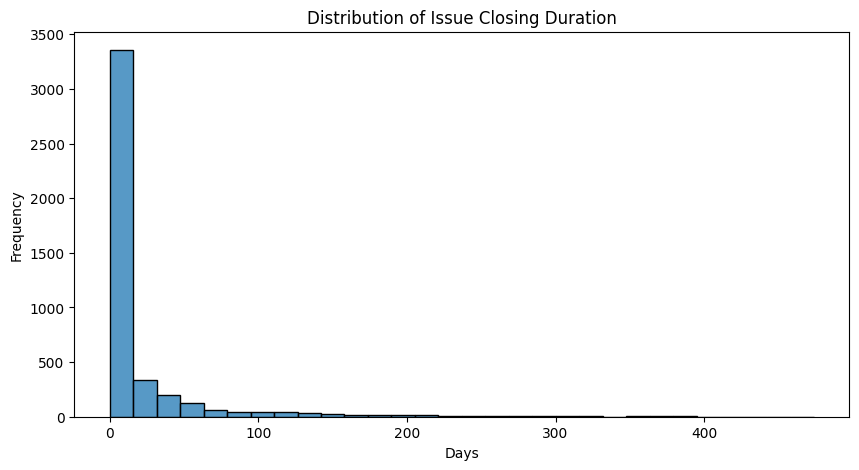

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    issues_df["close_duration_days"],
    bins=30
)

plt.title("Distribution of Issue Closing Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Visualization: Issue Status Count

Visualisasi ini menunjukkan perbandingan jumlah
issue berdasarkan statusnya, yaitu open dan closed.

Berdasarkan hasil visualisasi, jumlah issue dengan status
closed lebih banyak dibandingkan issue dengan status open.
Hal ini menunjukkan bahwa sebagian besar issue pada
repository pandas-dev/pandas telah berhasil diselesaikan.

Perbandingan jumlah issue open dan closed dapat memberikan
gambaran mengenai tingkat aktivitas dan efektivitas
pengelolaan issue dalam repository open-source.



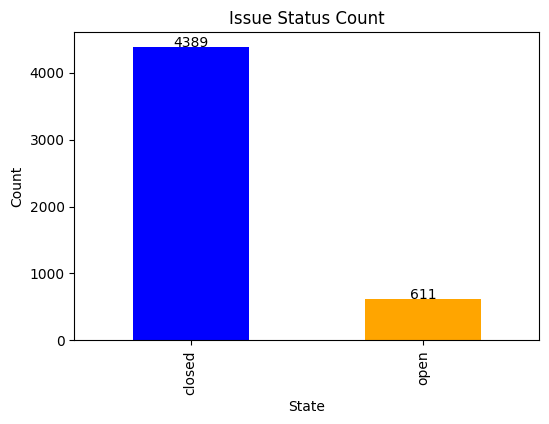

In [38]:
plt.figure(figsize=(6, 4))

ax = df["state"].value_counts().plot(
    kind="bar",
    color=["blue", "orange"]
)

# menampilkan jumlah di atas batang
for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height() + 5,
        str(int(i.get_height())),
        ha='center'
    )

plt.title("Issue Status Count")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

# Visualization: Issues Created Over Time

Visualisasi line chart ini menunjukkan tren jumlah
issue yang dibuat dari waktu ke waktu berdasarkan periode bulan.

Data created_at dikonversi menjadi format year-month
agar jumlah issue dapat dikelompokkan per bulan
dan divisualisasikan dalam bentuk time series.

Melalui grafik ini dapat diamati pola aktivitas repository,
seperti peningkatan maupun penurunan jumlah issue
pada periode tertentu.

Fluktuasi jumlah issue dapat menunjukkan:

* tingkat aktivitas pengguna repository
* peningkatan penggunaan project
* adanya update atau perubahan besar pada project
* peningkatan laporan bug atau request fitur baru

Analisis tren waktu seperti ini membantu memahami
perkembangan aktivitas repository secara keseluruhan.
ualization shows issue activity trends over time.

/tmp/ipykernel_2607/248647077.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


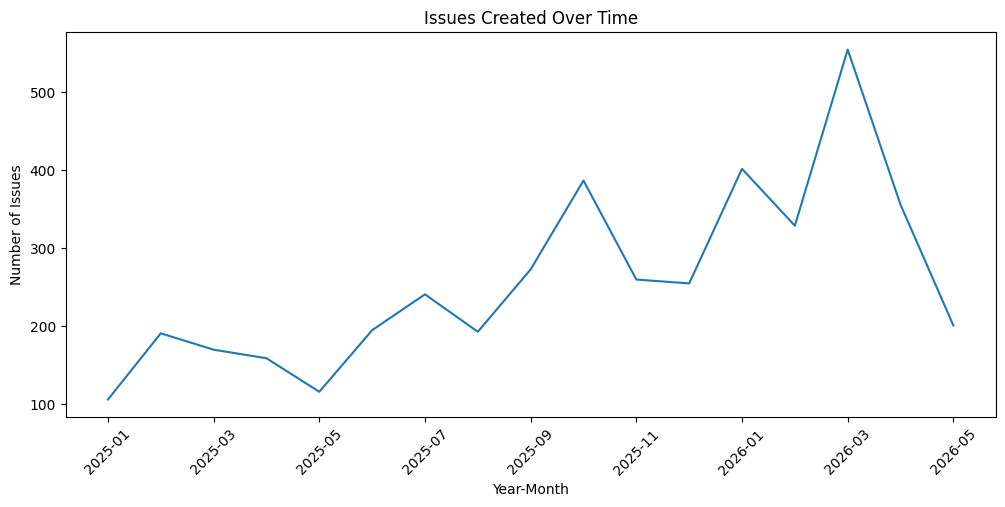

In [39]:
issues_df["year_month"] = (
    issues_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_issues = (
    issues_df["year_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

monthly_issues.plot()

plt.title("Issues Created Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Issues")

plt.xticks(rotation=45)

plt.show()

# Variable Selection

Pada bagian ini dipilih beberapa variabel
yang akan digunakan untuk proses analisis statistik
pada tahap selanjutnya.

Pemilihan variabel dilakukan berdasarkan
relevansi data terhadap research question
dan kebutuhan analisis seperti estimation,
inference, hypothesis testing, dan simulation.


In [40]:
variable_selection = pd.DataFrame({
    "Variable": [
        "is_closed",
        "close_duration_days",
        "comments"
    ],

    "Description": [
        "Status issue closed",
        "Durasi penutupan issue",
        "Jumlah komentar issue"
    ],

    "Statistical Usage": [
        "Bernoulli Estimation",
        "Confidence Interval & Hypothesis Testing",
        "Poisson Analysis"
    ]
})

variable_selection

,Variable,Description,Statistical Usage
0,is_closed,Status issue closed,Bernoulli Estimation
1,close_duration_days,Durasi penutupan issue,Confidence Interval & Hypothesis Testing
2,comments,Jumlah komentar issue,Poisson Analysis


# Pull Request Data Collection

Pada bagian ini dilakukan proses pengambilan
data pull request dari repository pandas-dev/pandas
menggunakan GitHub REST API.

Dataset pull request ini akan digunakan
untuk analisis statistik pada tahap berikutnya,
seperti:

* estimasi probabilitas pull request di-merge
* Bernoulli Maximum Likelihood Estimation (MLE)
* confidence interval
* hypothesis testing

Data yang dikumpulkan mencakup informasi
status pull request, waktu pembuatan,
waktu merge, dan waktu penutupan pull request.


In [41]:
# ============================================================
# PULL REQUEST DATA COLLECTION
# ============================================================

all_prs = []

# endpoint pull requests
PR_URL = (
    f"https://api.github.com/repos/"
    f"{OWNER}/{REPO}/pulls"
)

# mengambil beberapa halaman data
for page in range(1, 51):

    url = (
        f"{PR_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(
        url,
        headers=headers
    )

    # cek request berhasil
    if response.status_code != 200:
        print(f"Error collecting page {page}")
        print(response.text)
        break

    data = response.json()

    # berhenti jika data habis
    if len(data) == 0:
        break

    all_prs.extend(data)

    print(f"Collected PR page {page}")

print("Total Pull Requests:",
      len(all_prs))

Collected PR page 1
Collected PR page 2
Collected PR page 3
Collected PR page 4
Collected PR page 5
Collected PR page 6
Collected PR page 7
Collected PR page 8
Collected PR page 9
Collected PR page 10
Collected PR page 11
Collected PR page 12
Collected PR page 13
Collected PR page 14
Collected PR page 15
Collected PR page 16
Collected PR page 17
Collected PR page 18
Collected PR page 19
Collected PR page 20
Collected PR page 21
Collected PR page 22
Collected PR page 23
Collected PR page 24
Collected PR page 25
Collected PR page 26
Collected PR page 27
Collected PR page 28
Collected PR page 29
Collected PR page 30
Collected PR page 31
Collected PR page 32
Collected PR page 33
Collected PR page 34
Collected PR page 35
Collected PR page 36
Collected PR page 37
Collected PR page 38
Collected PR page 39
Collected PR page 40
Collected PR page 41
Collected PR page 42
Collected PR page 43
Collected PR page 44
Collected PR page 45
Collected PR page 46
Collected PR page 47
Collected PR page 48
C

# Convert Pull Request Data to DataFrame

Pada bagian ini, data pull request yang telah dikumpulkan dari GitHub REST API dalam format JSON akan dikonversi menjadi DataFrame menggunakan pandas.

Proses ini bertujuan untuk memudahkan pengolahan data, seperti filtering, cleaning, dan analisis statistik pada tahap selanjutnya.

Setelah dikonversi, data dapat dianalisis menggunakan berbagai metode seperti agregasi, visualisasi, dan perhitungan metrik statistik.


In [42]:
pr_df = pd.DataFrame(all_prs)

print(pr_df.shape)

pr_df.head()

(5000, 36)


,url,id,node_id,html_url,diff_url,patch_url,issue_url,number,state,locked,...,review_comment_url,comments_url,statuses_url,head,base,_links,author_association,auto_merge,assignee,active_lock_reason
0,https://api.github.com/repos/pandas-dev/pandas...,3770107824,PR_kwDOAA0YD87gt0ew,https://github.com/pandas-dev/pandas/pull/65753,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65753,closed,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'meeseeksmachine:auto-backport-of-pr...,"{'label': 'pandas-dev:3.0.x', 'ref': '3.0.x', ...",{'self': {'href': 'https://api.github.com/repo...,CONTRIBUTOR,None,None,None
1,https://api.github.com/repos/pandas-dev/pandas...,3767062229,PR_kwDOAA0YD87giM7V,https://github.com/pandas-dev/pandas/pull/65752,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65752,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'hanhan761:fix-map-series-mapper-dty...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,NONE,None,None,None
2,https://api.github.com/repos/pandas-dev/pandas...,3765970027,PR_kwDOAA0YD87geCRr,https://github.com/pandas-dev/pandas/pull/65751,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65751,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:depr-ragged', 'ref': '...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
3,https://api.github.com/repos/pandas-dev/pandas...,3765926178,PR_kwDOAA0YD87gd3ki,https://github.com/pandas-dev/pandas/pull/65750,https://github.com/pandas-dev/pandas/pull/6575...,https://github.com/pandas-dev/pandas/pull/6575...,https://api.github.com/repos/pandas-dev/pandas...,65750,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:bug-where', 'ref': 'bu...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
4,https://api.github.com/repos/pandas-dev/pandas...,3765856975,PR_kwDOAA0YD87gdmrP,https://github.com/pandas-dev/pandas/pull/65749,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65749,closed,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'jbrockmendel:bug-ragged', 'ref': 'b...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None


# Save Raw Pull Request Dataset

Pada bagian ini, dataset pull request yang telah dikumpulkan disimpan dalam bentuk file CSV tanpa dilakukan perubahan atau preprocessing.

Tujuan penyimpanan ini adalah untuk menjaga data asli (raw data) dari GitHub REST API agar dapat digunakan kembali jika diperlukan proses analisis ulang.

Output dari proses ini disimpan pada:

* `data/raw/pull_requests_raw.csv`


In [43]:
pr_df.to_csv(
    "../data/raw/pull_requests_raw.csv",
    index=False
)

print("pull_requests_raw.csv saved.")

pull_requests_raw.csv saved.


# Pull Request Data Cleaning

Pada bagian ini dilakukan proses pembersihan dataset pull request agar siap digunakan untuk analisis statistik.

Proses cleaning meliputi:

* pemilihan kolom yang relevan untuk analisis
* konversi data waktu (datetime conversion)
* penanganan nilai yang hilang (missing values)
* pembuatan fitur baru (feature engineering)

Setelah proses ini, dataset menjadi lebih terstruktur dan siap digunakan untuk analisis lanjutan seperti estimasi, visualisasi, dan pengujian statistik.


In [44]:
pr_clean = pr_df[
    [
        "id",
        "number",
        "state",
        "created_at",
        "closed_at",
        "merged_at"
    ]
].copy()

print(pr_clean.shape)

pr_clean.head()

(5000, 6)


,id,number,state,created_at,closed_at,merged_at
0,3770107824,65753,closed,2026-05-29T16:05:26Z,2026-05-29T16:36:56Z,2026-05-29T16:36:56Z
1,3767062229,65752,open,2026-05-29T06:48:57Z,None,None
2,3765970027,65751,open,2026-05-29T01:53:15Z,None,None
3,3765926178,65750,open,2026-05-29T01:40:55Z,None,None
4,3765856975,65749,closed,2026-05-29T01:17:28Z,2026-05-29T16:13:29Z,2026-05-29T16:13:29Z


# Datetime Conversion

Pada bagian ini, variabel yang berupa timestamp diubah ke dalam format datetime menggunakan pandas.

Proses ini diperlukan agar data waktu dapat dianalisis secara lebih akurat, terutama untuk perhitungan durasi, seperti waktu penyelesaian issue atau pull request.

Dengan format datetime, data dapat digunakan untuk analisis statistik seperti:

* perhitungan selisih waktu (time delta)
* analisis tren waktu
* pengelompokan berdasarkan periode (hari, bulan, tahun)


In [45]:
pr_clean["created_at"] = pd.to_datetime(
    pr_clean["created_at"]
)

pr_clean["closed_at"] = pd.to_datetime(
    pr_clean["closed_at"]
)

pr_clean["merged_at"] = pd.to_datetime(
    pr_clean["merged_at"]
)

# Pull Request Feature Engineering

Pada bagian ini dilakukan proses pembuatan variabel tambahan (feature engineering) untuk mendukung analisis statistik pada dataset pull request.

Variabel yang dibuat meliputi:

* **merged**: indikator apakah pull request berhasil di-merge atau tidak (bernilai 1 jika merged, 0 jika tidak)
* **review_duration_days**: durasi waktu review atau penyelesaian pull request dalam satuan hari

Variabel ini digunakan untuk analisis lebih lanjut seperti estimasi probabilitas merge, distribusi durasi, serta pengujian statistik.


In [46]:
# merged PR indicator
pr_clean["merged"] = (
    pr_clean["merged_at"].notna()
).astype(int)

# review duration
pr_clean["review_duration_days"] = (
    pr_clean["closed_at"] - pr_clean["created_at"]
).dt.days

pr_clean.head()

,id,number,state,created_at,closed_at,merged_at,merged,review_duration_days
0,3770107824,65753,closed,2026-05-29 16:05:26+00:00,2026-05-29 16:36:56+00:00,2026-05-29 16:36:56+00:00,1,0.0
1,3767062229,65752,open,2026-05-29 06:48:57+00:00,NaT,NaT,0,NaN
2,3765970027,65751,open,2026-05-29 01:53:15+00:00,NaT,NaT,0,NaN
3,3765926178,65750,open,2026-05-29 01:40:55+00:00,NaT,NaT,0,NaN
4,3765856975,65749,closed,2026-05-29 01:17:28+00:00,2026-05-29 16:13:29+00:00,2026-05-29 16:13:29+00:00,1,0.0


# Save Clean Pull Request Dataset

Pada bagian ini, dataset pull request yang telah melalui proses cleaning dan feature engineering disimpan ke dalam file CSV.

Penyimpanan ini bertujuan untuk menyediakan dataset yang sudah siap digunakan pada tahap analisis statistik selanjutnya.

Output dari proses ini disimpan pada:

* `data/clean/pr_dataset.csv`


In [47]:
pr_clean.to_csv(
    "../data/clean/pr_dataset.csv",
    index=False
)

print("pr_dataset.csv saved.")

pr_dataset.csv saved.


# Visualization: Pull Request Merge Status

Visualisasi ini menunjukkan perbandingan jumlah pull request yang berhasil di-merge dan yang tidak di-merge dalam repository.

Hasil visualisasi ini digunakan untuk memahami distribusi status pull request, yang menjadi dasar dalam analisis statistik.

Variabel ini penting karena digunakan untuk:

* estimasi Bernoulli (merged vs not merged)
* analisis probabilitas merge
* konstruksi confidence interval


/tmp/ipykernel_2607/3119565246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


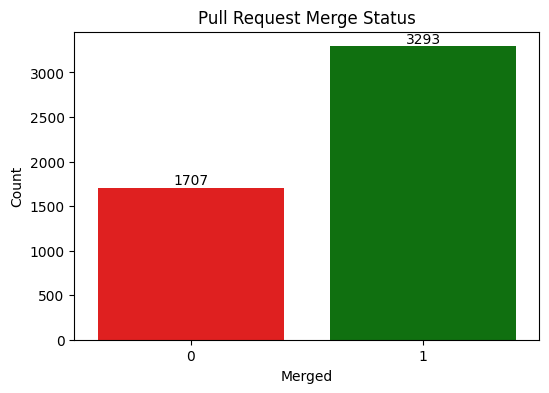

In [48]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="merged",
    data=pr_clean,
    palette=["red", "green"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Pull Request Merge Status")
plt.xlabel("Merged")
plt.ylabel("Count")

plt.show()

## Penjelasan Visualization: PR Review Duration

Distribusi durasi review pull request menunjukkan pola **right-skewed (skewed ke kanan)**.

Artinya sebagian besar pull request memiliki durasi review yang cepat, tetapi terdapat beberapa pull request dengan durasi sangat lama yang menyebabkan ekor distribusi memanjang ke kanan.

Pada kondisi ini, nilai mean cenderung lebih besar dibanding median karena dipengaruhi oleh nilai ekstrem (outlier).


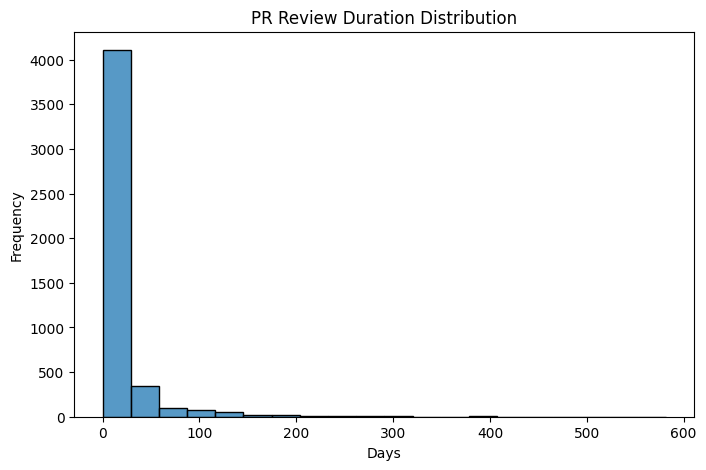

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    pr_clean["review_duration_days"].dropna(),
    bins=20
)

plt.title("PR Review Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

## Visualization: Pull Request Activity Over Time

Visualisasi ini menunjukkan jumlah pull request yang dibuat dari waktu ke waktu berdasarkan periode bulanan.

Grafik ini digunakan untuk melihat pola aktivitas kontribusi pada repository, termasuk periode ketika pengembangan sedang aktif atau melambat.

Dengan analisis ini, kita dapat memahami tren perkembangan proyek serta dinamika kontribusi developer dari waktu ke waktu.


/tmp/ipykernel_2607/1892979126.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


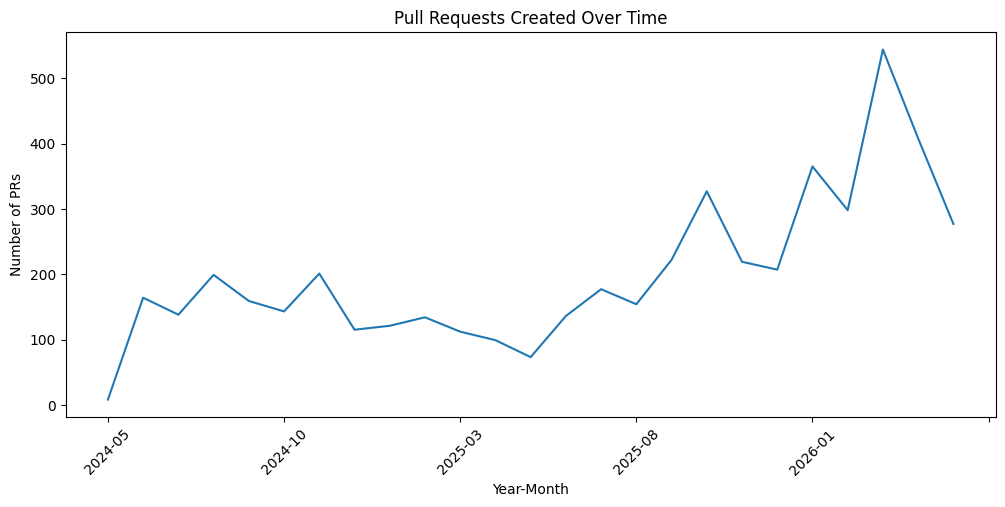

In [50]:
pr_clean["year_month"] = (
    pr_clean["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_pr = (
    pr_clean["year_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

monthly_pr.plot()

plt.title("Pull Requests Created Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of PRs")

plt.xticks(rotation=45)

plt.show()

## Ringkasan

Notebook ini berhasil menyelesaikan proses data engineering untuk statistical audit pada repository `pandas-dev/pandas`.

Proses yang dilakukan meliputi:

* pengumpulan data issue dan pull request dari GitHub API
* penyimpanan dataset raw
* data cleaning dan preprocessing
* feature engineering
* exploratory data analysis (EDA)
* visualisasi statistik

Dataset yang dihasilkan:

* Raw: `data/raw/issues_raw.csv`, `data/raw/pull_requests_raw.csv`
* Clean: `data/clean/dataset.csv`, `data/clean/pr_dataset.csv`

Variabel utama yang digunakan untuk analisis lanjutan:

* durasi penutupan issue
* frekuensi aktivitas issue
* status merge pull request
* durasi review pull request

Dataset ini akan digunakan pada tahap berikutnya untuk:

* estimasi parameter
* confidence interval
* hypothesis testing
* simulasi komputasi

Notebook ini menjadi fondasi utama untuk seluruh analisis statistik pada project ini.
